# Modelisation

In [2]:
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
pd.set_option('display.max_row', 20)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 500)

In [4]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))

# Import des bases de données

In [10]:
df = pd.read_csv('data.csv', nrows=None)
#df = pd.read_parquet("data.parquet")
df.shape

(356251, 463)

In [12]:
# Conversion des floats 64 → float32
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].astype("float32")

# Conversion des int 64 → int32
int_cols = df.select_dtypes(include=["int64"]).columns
df[int_cols] = df[int_cols].astype("int32")

# Conversion des bool → int8 (suffisant et plus léger)
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype("int8")

In [13]:
# File system management
import os
import pickle
import dill

from collections import Counter

# Data manipulation
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.model_selection import cross_val_predict, cross_validate, cross_val_score, train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler

# Hyperparameters optimisation
from hyperopt import tpe, hp, fmin, space_eval, STATUS_OK, Trials, SparkTrials
from hyperopt.pyll.base import scope

# XGBoost
import xgboost as xgb

# LightGBM
import lightgbm as ltb

# Balancing data
from imblearn.over_sampling import SMOTE

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Interpratability

import shap


# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(palette="Set1")

In [14]:
df = df.replace([np.inf, -np.inf], np.nan)

# Split du dataset

In [15]:
df.shape

(356251, 463)

In [16]:
# Define usefull variables
TARGET = 'TARGET'
ID = 'SK_ID_CURR'

In [17]:
# === Split train / test avant tout ===
train_df = df[df['TARGET'].notna()].copy()
test_df  = df[df['TARGET'].isna()].copy()


In [18]:
display(test_df.head())
display(train_df.head())

,Unnamed: 0,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
307507,307507,100001,NaN,1,0,0,0,135000.0,568800.0,20560.5,0.018850,-19241,-2329.0,-5170.0,-812,0,0,1,2.0,2,18,0,0,0,0,...,11.0,1.571429,11.0,36.0,8.857142,62.0,1.0,1.000000,7.0,0.000000,0.000000,0.00000,0.000000,0.00,17397.900391,5885.132324,4.119593e+04,3951.000000,17397.900391,5885.132324,4.119593e+04,-1628.0,-2195.000000,-15365.0,7.0
307508,307508,100005,NaN,0,0,0,0,99000.0,222768.0,17370.0,0.035792,-18064,-4469.0,-9118.0,-1623,0,0,0,2.0,2,9,0,0,0,0,...,1.0,0.111111,1.0,37.0,23.666666,213.0,1.0,1.000000,9.0,0.000000,0.000000,0.00000,0.000000,0.00,17656.244141,6240.205078,5.616184e+04,4813.200195,17656.244141,6240.205078,5.616184e+04,-470.0,-609.555542,-5486.0,9.0
307509,307509,100013,NaN,0,1,0,0,202500.0,663264.0,69777.0,0.019101,-20038,-4458.0,-2175.0,-3503,0,0,0,2.0,2,14,0,0,0,0,...,21.0,0.541936,84.0,38.0,5.722580,887.0,1.0,0.935484,145.0,0.058241,23147.820312,1157.66272,179437.718750,23467724.00,357347.750000,10897.898438,1.689174e+06,6.165000,357347.750000,9740.235352,1.509736e+06,-14.0,-1358.109619,-210507.0,155.0
307510,307510,100028,NaN,1,0,0,2,315000.0,1575000.0,49018.5,0.026392,-13976,-1866.0,-2000.0,-4208,0,1,0,4.0,2,11,0,0,0,0,...,7.0,0.265487,30.0,19.0,3.265487,369.0,1.0,0.911504,103.0,0.045393,8505.000000,622.55072,70348.226562,2972475.75,38988.539062,4979.282227,5.626589e+05,1.170000,38988.539062,4356.731445,4.923107e+05,-29.0,-858.548645,-97016.0,113.0
307511,307511,100038,NaN,0,1,1,1,180000.0,625500.0,32067.0,0.010032,-13040,-2191.0,-4000.0,-4262,1,0,0,3.0,2,5,0,0,0,0,...,0.0,0.000000,0.0,18.0,12.250000,147.0,1.0,1.000000,12.0,0.000000,0.000000,0.00000,0.000000,0.00,11100.599609,11100.337891,1.332040e+05,11097.450195,11100.599609,11100.337891,1.332040e+05,-466.0,-634.250000,-7611.0,12.0


,Unnamed: 0,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
0,0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,0.018801,-9461,-637.0,-3648.0,-2120,0,1,0,1.0,2,10,0,0,0,0,...,0.0,0.000000,0.0,31.0,20.421053,388.0,1.0,1.000000,19.0,0.000000,0.000000,0.000000,0.000000,0.0,53093.746094,11559.247070,2.196257e+05,9251.775391,53093.746094,11559.247070,2.196257e+05,-49.0,-315.421051,-5993.0,19.0
1,1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188.0,-1186.0,-291,0,1,0,2.0,1,11,0,0,0,0,...,0.0,0.000000,0.0,14.0,7.160000,179.0,1.0,1.000000,25.0,0.000000,0.000000,0.000000,0.000000,0.0,560835.375000,64754.585938,1.618865e+06,6662.970215,560835.375000,64754.585938,1.618865e+06,-544.0,-1385.319946,-34633.0,25.0
2,2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,0.010032,-19046,-225.0,-4260.0,-2531,1,1,0,1.0,2,9,0,0,0,0,...,0.0,0.000000,0.0,11.0,7.666667,23.0,1.0,1.000000,3.0,0.000000,0.000000,0.000000,0.000000,0.0,10573.964844,7096.154785,2.128846e+04,5357.250000,10573.964844,7096.154785,2.128846e+04,-727.0,-761.666687,-2285.0,3.0
3,3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,0.008019,-19005,-3039.0,-9833.0,-2437,0,0,0,2.0,2,17,0,0,0,0,...,0.0,0.000000,0.0,77.0,19.375000,310.0,1.0,1.000000,16.0,0.000000,0.000000,0.000000,0.000000,0.0,691786.875000,62947.089844,1.007153e+06,2482.919922,691786.875000,62947.089844,1.007153e+06,-12.0,-271.625000,-4346.0,16.0
4,4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,0.028663,-19932,-3038.0,-4311.0,-3458,0,0,0,1.0,2,11,0,0,0,0,...,12.0,0.954545,63.0,31.0,4.590909,303.0,1.0,0.954545,63.0,0.043995,22655.654297,452.384308,29857.365234,8084830.0,22678.785156,12666.444336,8.359853e+05,0.180000,22678.785156,12214.060547,8.061280e+05,-14.0,-1032.242432,-68128.0,66.0


In [19]:
# variables
TARGET = 'TARGET'
ID = 'SK_ID_CURR'

In [20]:
test_df = test_df.drop(columns=['Unnamed: 0'])
train_df= train_df.drop(columns=['Unnamed: 0'])

In [21]:
display(test_df.shape)
display(train_df.shape)

display(test_df.head())
display(train_df.head())

(48744, 462)

(307507, 462)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
307507,100001,NaN,1,0,0,0,135000.0,568800.0,20560.5,0.018850,-19241,-2329.0,-5170.0,-812,0,0,1,2.0,2,18,0,0,0,0,0,...,11.0,1.571429,11.0,36.0,8.857142,62.0,1.0,1.000000,7.0,0.000000,0.000000,0.00000,0.000000,0.00,17397.900391,5885.132324,4.119593e+04,3951.000000,17397.900391,5885.132324,4.119593e+04,-1628.0,-2195.000000,-15365.0,7.0
307508,100005,NaN,0,0,0,0,99000.0,222768.0,17370.0,0.035792,-18064,-4469.0,-9118.0,-1623,0,0,0,2.0,2,9,0,0,0,0,0,...,1.0,0.111111,1.0,37.0,23.666666,213.0,1.0,1.000000,9.0,0.000000,0.000000,0.00000,0.000000,0.00,17656.244141,6240.205078,5.616184e+04,4813.200195,17656.244141,6240.205078,5.616184e+04,-470.0,-609.555542,-5486.0,9.0
307509,100013,NaN,0,1,0,0,202500.0,663264.0,69777.0,0.019101,-20038,-4458.0,-2175.0,-3503,0,0,0,2.0,2,14,0,0,0,0,0,...,21.0,0.541936,84.0,38.0,5.722580,887.0,1.0,0.935484,145.0,0.058241,23147.820312,1157.66272,179437.718750,23467724.00,357347.750000,10897.898438,1.689174e+06,6.165000,357347.750000,9740.235352,1.509736e+06,-14.0,-1358.109619,-210507.0,155.0
307510,100028,NaN,1,0,0,2,315000.0,1575000.0,49018.5,0.026392,-13976,-1866.0,-2000.0,-4208,0,1,0,4.0,2,11,0,0,0,0,0,...,7.0,0.265487,30.0,19.0,3.265487,369.0,1.0,0.911504,103.0,0.045393,8505.000000,622.55072,70348.226562,2972475.75,38988.539062,4979.282227,5.626589e+05,1.170000,38988.539062,4356.731445,4.923107e+05,-29.0,-858.548645,-97016.0,113.0
307511,100038,NaN,0,1,1,1,180000.0,625500.0,32067.0,0.010032,-13040,-2191.0,-4000.0,-4262,1,0,0,3.0,2,5,0,0,0,0,1,...,0.0,0.000000,0.0,18.0,12.250000,147.0,1.0,1.000000,12.0,0.000000,0.000000,0.00000,0.000000,0.00,11100.599609,11100.337891,1.332040e+05,11097.450195,11100.599609,11100.337891,1.332040e+05,-466.0,-634.250000,-7611.0,12.0


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,0.018801,-9461,-637.0,-3648.0,-2120,0,1,0,1.0,2,10,0,0,0,0,0,...,0.0,0.000000,0.0,31.0,20.421053,388.0,1.0,1.000000,19.0,0.000000,0.000000,0.000000,0.000000,0.0,53093.746094,11559.247070,2.196257e+05,9251.775391,53093.746094,11559.247070,2.196257e+05,-49.0,-315.421051,-5993.0,19.0
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188.0,-1186.0,-291,0,1,0,2.0,1,11,0,0,0,0,0,...,0.0,0.000000,0.0,14.0,7.160000,179.0,1.0,1.000000,25.0,0.000000,0.000000,0.000000,0.000000,0.0,560835.375000,64754.585938,1.618865e+06,6662.970215,560835.375000,64754.585938,1.618865e+06,-544.0,-1385.319946,-34633.0,25.0
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,0.010032,-19046,-225.0,-4260.0,-2531,1,1,0,1.0,2,9,0,0,0,0,0,...,0.0,0.000000,0.0,11.0,7.666667,23.0,1.0,1.000000,3.0,0.000000,0.000000,0.000000,0.000000,0.0,10573.964844,7096.154785,2.128846e+04,5357.250000,10573.964844,7096.154785,2.128846e+04,-727.0,-761.666687,-2285.0,3.0
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,0.008019,-19005,-3039.0,-9833.0,-2437,0,0,0,2.0,2,17,0,0,0,0,0,...,0.0,0.000000,0.0,77.0,19.375000,310.0,1.0,1.000000,16.0,0.000000,0.000000,0.000000,0.000000,0.0,691786.875000,62947.089844,1.007153e+06,2482.919922,691786.875000,62947.089844,1.007153e+06,-12.0,-271.625000,-4346.0,16.0
4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,0.028663,-19932,-3038.0,-4311.0,-3458,0,0,0,1.0,2,11,0,0,0,0,1,...,12.0,0.954545,63.0,31.0,4.590909,303.0,1.0,0.954545,63.0,0.043995,22655.654297,452.384308,29857.365234,8084830.0,22678.785156,12666.444336,8.359853e+05,0.180000,22678.785156,12214.060547,8.061280e+05,-14.0,-1032.242432,-68128.0,66.0


# Split feature target

In [22]:
X = train_df.drop(columns=[ID, TARGET])
y = train_df[TARGET].astype(int)

X_test = test_df.drop(columns=[TARGET], errors="ignore")

**Split interne**

In [23]:
#Split interne
from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [24]:
import mlflow
mlflow.sklearn.autolog()

# 1_ Baseline (Sans équilibrage de données)

In [18]:
#Étape 1 : Modèle baseline DummyClassifier

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier

mlflow.set_experiment("credit_risk_dummy_model_mf")

dummy_baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DummyClassifier(
        strategy="most_frequent",  # classe majoritaire
        random_state=42
    ))
])


# Étape 2: Entraînement et prédictions
dummy_baseline.fit(X_tr, y_tr)

# Probabilités
proba_va_dummy = dummy_baseline.predict_proba(X_va)[:, 1]

# Prédictions avec seuil 0.5
y_pred_05_dummy = (proba_va_dummy >= 0.5).astype(int)

# Étape 3  : Évaluation
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, classification_report,
    confusion_matrix
)
print("=== DummyClassifier (baseline naïve) ===")
print("ROC-AUC :", roc_auc_score(y_va, proba_va_dummy))
print("PR-AUC  :", average_precision_score(y_va, proba_va_dummy))
print("Accuracy:", accuracy_score(y_va, y_pred_05_dummy))
print("F1      :", f1_score(y_va, y_pred_05_dummy))

print("\n=== Classification report (0.5) ===")
print(classification_report(y_va, y_pred_05_dummy, digits=3))

print("Confusion matrix (0.5):\n",
      confusion_matrix(y_va, y_pred_05_dummy))

2026/01/08 21:46:03 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '89b750f4db624a2891ee0a6521d746a3', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow2026/01/08 21:46:42 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integ

=== DummyClassifier (baseline naïve) ===
ROC-AUC : 0.5
PR-AUC  : 0.08072908198107379
Accuracy: 0.9192709180189262
F1      : 0.0

=== Classification report (0.5) ===
              precision    recall  f1-score   support

           0      0.919     1.000     0.958     56537
           1      0.000     0.000     0.000      4965

    accuracy                          0.919     61502
   macro avg      0.460     0.500     0.479     61502
weighted avg      0.845     0.919     0.881     61502

Confusion matrix (0.5):
 [[56537     0]
 [ 4965     0]]

C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [22]:
#Étape 1 : Modèle baseline DummyClassifier

mlflow.set_experiment("credit_risk_dummy_model_s")

dummy_baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DummyClassifier(
        strategy="stratified",  # aléatoire
        random_state=42
    ))
])

# Étape 2: Entraînement et prédictions
dummy_baseline.fit(X_tr, y_tr)

# Probabilités
proba_va_dummy = dummy_baseline.predict_proba(X_va)[:, 1]

# Prédictions avec seuil 0.5
y_pred_05_dummy = (proba_va_dummy >= 0.5).astype(int)

# Étape 3  : Évaluation
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, classification_report,
    confusion_matrix
)
print("=== DummyClassifier (baseline naïve) ===")
print("ROC-AUC :", roc_auc_score(y_va, proba_va_dummy))
print("PR-AUC  :", average_precision_score(y_va, proba_va_dummy))
print("Accuracy:", accuracy_score(y_va, y_pred_05_dummy))
print("F1      :", f1_score(y_va, y_pred_05_dummy))

print("\n=== Classification report (0.5) ===")
print(classification_report(y_va, y_pred_05_dummy, digits=3))

print("Confusion matrix (0.5):\n",
      confusion_matrix(y_va, y_pred_05_dummy))

2026/01/06 23:10:36 INFO mlflow.tracking.fluent: Experiment with name 'credit_risk_dummy_model_s' does not exist. Creating a new experiment.2026/01/06 23:10:36 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '26981bc7d12246f8acc8035c9a3a7c4a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow2026/01/06 23:11:36 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing val

=== DummyClassifier (baseline naïve) ===
ROC-AUC : 0.5033367164078186
PR-AUC  : 0.08126237061859376
Accuracy: 0.8532893239244252
F1      : 0.08646350106307583

=== Classification report (0.5) ===
              precision    recall  f1-score   support

           0      0.920     0.921     0.920     56537
           1      0.087     0.086     0.086      4965

    accuracy                          0.853     61502
   macro avg      0.503     0.503     0.503     61502
weighted avg      0.853     0.853     0.853     61502

Confusion matrix (0.5):
 [[52052  4485]
 [ 4538   427]]

# 2 _ Equilibrage de données

In [25]:

# pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate

from imblearn.pipeline import Pipeline as ImbPipeline


In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, make_scorer

COST_FN = 10.0  # coût FN
COST_FP = 1.0   # coût FP

def min_business_cost(y_true, y_proba, cost_fn=COST_FN, cost_fp=COST_FP):
    """
    Retourne le coût métier minimal (plus petit = mieux)
    en optimisant le seuil à partir des probabilités.

    y_proba : soit vecteur (n_samples,), soit matrice (n_samples, 2) de predict_proba
    """
    y_proba = np.asarray(y_proba)

    # Si on reçoit un tableau (n, 2) => proba de la classe positive = colonne 1
    if y_proba.ndim == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba

    # Seuils candidats = valeurs uniques des scores prédits
    thresholds = np.unique(y_score)

    best_cost = np.inf

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        cost = (cost_fp * fp + cost_fn * fn) / len(y_true)
        if cost < best_cost:
            best_cost = cost

    return float(best_cost)


In [27]:
business_cost_scorer = make_scorer(
    min_business_cost,
    response_method="predict_proba",  # on veut les probas
    greater_is_better=False           # on MINIMISE le coût
)


In [28]:

# Paramètres de base
logreg_params = {"max_iter": 2000, "solver": "lbfgs", "random_state": 42}

# CV légère pour RAM
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# Définition des métriques de scoring

scoring = {
    "roc_auc":   "roc_auc",
    "pr_auc":    "average_precision",
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, average="binary", zero_division=0),
    "recall":    make_scorer(recall_score, average="binary", zero_division=0),
    "f1":        make_scorer(f1_score, average="binary", zero_division=0),
    "biz_cost":  business_cost_scorer,   # Ajout du score métier
}


# Fonction d’évaluation cross-val
def cv_table(model, X, y):
    out = cross_validate(
        model, X, y, cv=cv, scoring=scoring,
        n_jobs=1,
        error_score="raise",
        return_train_score=False
    )
    rows = []
    for k, v in out.items():
        if k.startswith("test_"):
            metric = k.replace("test_", "")

            # Pour biz_cost, sklearn a mis un signe -, on le remet dans le bon sens
            if metric == "biz_cost":
                v = -v   # on repasse au coût positif

            rows.append({
                "metric": metric,
                "mean": float(np.mean(v)),
                "std":  float(np.std(v))
            })
    rep = pd.DataFrame(rows).set_index("metric").sort_index()

    return rep

In [29]:
def find_best_threshold(y_true, y_proba, cost_fn=COST_FN, cost_fp=COST_FP):
    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba

    thresholds = np.unique(y_score)

    best_cost = np.inf
    best_t = None

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        cost = (cost_fp * fp + cost_fn * fn) / len(y_true)
        if cost < best_cost:
            best_cost = cost
            best_t = t

    return float(best_cost), float(best_t)

In [30]:
import pandas as pd

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [23]:


# 1) Base pipeline RF (sans resampling)
def make_rf_pipe(resampling_steps=None):
    steps = [("imp", SimpleImputer(strategy="median"))]
    if resampling_steps:
        steps += resampling_steps
    steps += [("clf", RandomForestClassifier(random_state=42, n_jobs=-1))]
    return ImbPipeline(steps=steps)
    
# 2) Définir les 4 variantes "jeux de données" (comme ta logreg)
pipes = {
    "RF_weight": make_rf_pipe(resampling_steps=None),  # class_weight géré dans la grille
    "RF_Under": make_rf_pipe(resampling_steps=[
        ("under", RandomUnderSampler(sampling_strategy=0.5, random_state=42))
    ]),
    "RF_SMOTE": make_rf_pipe(resampling_steps=[
        ("over", SMOTE(sampling_strategy=0.5, random_state=42))
    ]),
    "RF_SMOTE_Under": make_rf_pipe(resampling_steps=[
        ("over", SMOTE(sampling_strategy=0.5, random_state=42)),
        ("under", RandomUnderSampler(sampling_strategy=1.0, random_state=42))
    ]),
}

In [ ]:



# 3) Grille d'hyperparamètres RF (inclut la règle métier FN=10xFP)
param_grid = {
    "clf__n_estimators": [200, 400, 800],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [5, 10, 20],
    "clf__max_features": ["sqrt", "log2"],
    "clf__class_weight": [
        "balanced",
        {0: 1, 1: 5},
        {0: 1, 1: 10},  # FN = 10x FP (traduction directe)
    ],
}

# 4) Tuning : GridSearchCV pour chaque pipeline
# Choisis UN scoring pour la GridSearch (souvent PR-AUC ou biz_cost custom)
SCORING = "average_precision"  # = PR-AUC

best_estimators = {}
best_rows = []

for name, pipe in pipes.items():
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=SCORING,
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_tr, y_tr)

    best_estimators[name] = gs.best_estimator_
    best_rows.append({
        "model": name,
        "best_score_cv(PR-AUC)": gs.best_score_,
        "best_params": gs.best_params_
    })

best_summary = pd.DataFrame(best_rows).sort_values("best_score_cv(PR-AUC)", ascending=False)
print("\n=== Best configs (GridSearchCV) ===")
print(best_summary[["model", "best_score_cv(PR-AUC)"]])

# les params détaillés :
print(best_summary[["model", "best_params"]].to_string(index=False))


# 5) Comparatif final : CV multi-métriques sur les BEST estimators (comme ton tableau LogReg)
reports = {}
for name, best_pipe in best_estimators.items():
    rep = cv_table(best_pipe, X_tr, y_tr)          # ton utilitaire -> mean/std par métrique
    reports[name] = rep["mean"] if "mean" in rep.columns else rep  # au cas où

df_compare = pd.DataFrame(reports)
print("\n=== Comparatif (moyennes CV) - BEST RF ===")
print(df_compare)


In [36]:
pipes["RF_weight"]

,steps,"[('imp', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,100


**1) LogReg avec class_weight="balanced"***

In [24]:
pipe_weight_logreg = ImbPipeline(steps=[

    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("clf",   LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

rep_weight = cv_table(pipe_weight_logreg, X_tr, y_tr)
print("\n=== LogReg_weight ===")
print(rep_weight.sort_values("mean", ascending=False))



=== LogReg_weight ===
               mean       std
metric                       
roc_auc    0.766519  0.002598
accuracy   0.702083  0.000497
recall     0.695720  0.005101
biz_cost   0.514685  0.002942
f1         0.273810  0.001365
pr_auc     0.239459  0.004503
precision  0.170446  0.000762


**2) LogReg + SMOTE (oversampling)**

In [28]:
pipe_over_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("over",  SMOTE(sampling_strategy=0.5, random_state=42)),
    ("clf",   LogisticRegression(**logreg_params))
])

rep_over = cv_table(pipe_over_logreg, X_tr, y_tr)
print("\n=== LogReg_SMOTE ===")
print(rep_over.sort_values("mean", ascending=False))



=== LogReg_SMOTE ===
               mean       std
metric                       
accuracy   0.832036  0.000561
roc_auc    0.751867  0.001726
biz_cost   0.535806  0.003868
recall     0.441440  0.004691
f1         0.297915  0.001525
pr_auc     0.227948  0.005394
precision  0.224825  0.000529


In [ ]:
SCORING = "average_precision"  # PR-AUC
best_estimators = {}
best_rows = []

# 3) Grille d'hyperparamètres RF (inclut la règle métier FN=10xFP)
param_grid = {
    "clf__n_estimators": [200], #400, 800],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [5, 10], #, 20],
    "clf__max_features": ["sqrt", "log2"],
    "clf__class_weight": [
        "balanced",
        {0: 1, 1: 5}
        #{0: 1, 1: 10},  # FN = 10x FP (traduction directe)
    ],
}


gs = GridSearchCV(
        estimator=pipes["RF_weight"],
        param_grid=param_grid,
        scoring=SCORING,
        cv=5,
        n_jobs=-1,
        verbose=0
    )

gs.fit(X_tr, y_tr)

best_estimators[name] = gs.best_estimator_
best_rows.append({
    "model": name,
    "best_score_cv(PR-AUC)": gs.best_score_,
    "best_params": gs.best_params_
})

best_summary = pd.DataFrame(best_rows).sort_values("best_score_cv(PR-AUC)", ascending=False)
print("\n=== Best configs (GridSearchCV) ===")
print(best_summary[["model", "best_score_cv(PR-AUC)"]])

2026/01/07 22:27:41 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f797137279aa44c3aab5ab62f3775b10', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow2026/01/07 22:28:19 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integ

**3) LogReg + undersampling**

In [29]:
pipe_under_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("under", RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ("clf",   LogisticRegression(**logreg_params))
])

rep_under = cv_table(pipe_under_logreg, X_tr, y_tr)
print("\n=== LogReg_Under ===")
print(rep_under.sort_values("mean", ascending=False))


=== LogReg_Under ===
               mean       std
metric                       
accuracy   0.838987  0.001082
roc_auc    0.765042  0.002925
biz_cost   0.517111  0.004408
recall     0.447734  0.006380
f1         0.309848  0.002847
pr_auc     0.237083  0.004553
precision  0.236905  0.001928


**4LogReg + SMOTE puis undersampling**

In [30]:
pipe_smote_under_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("over",  SMOTE(sampling_strategy=0.5, random_state=42)),
    ("under", RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
    ("clf",   LogisticRegression(max_iter=2000, random_state=42))
])

rep_smote_under = cv_table(pipe_smote_under_logreg, X_tr, y_tr)
print("\n=== LogReg_SMOTE_Under ===")
print(rep_smote_under.sort_values("mean", ascending=False))


=== LogReg_SMOTE_Under ===
               mean       std
metric                       
roc_auc    0.752680  0.001790
accuracy   0.709042  0.001314
recall     0.662135  0.005080
biz_cost   0.535306  0.004351
f1         0.268708  0.002387
pr_auc     0.226749  0.005125
precision  0.168555  0.001550


In [31]:
# comparaison
comparatif = []
if 'rep_weight' in globals():      comparatif.append(("LogReg_weight", rep_weight))
if 'rep_over' in globals():        comparatif.append(("LogReg_SMOTE", rep_over))
if 'rep_under' in globals():       comparatif.append(("LogReg_Under", rep_under))
if 'rep_smote_under' in globals(): comparatif.append(("LogReg_SMOTE_Under", rep_smote_under))


if comparatif:
    table = pd.concat(
        {name: rep['mean'] for name, rep in comparatif},
        axis=1
    )
    print("\n=== Comparatif (moyennes CV) ===")
    display(table.sort_values(by=table.columns[0], ascending=False))


=== Comparatif (moyennes CV) ===


,LogReg_weight,LogReg_SMOTE,LogReg_Under,LogReg_SMOTE_Under
metric,,,,
roc_auc,0.766519,0.751867,0.765042,0.752680
accuracy,0.702083,0.832036,0.838987,0.709042
recall,0.695720,0.441440,0.447734,0.662135
biz_cost,0.514685,0.535806,0.517111,0.535306
f1,0.273810,0.297915,0.309848,0.268708
pr_auc,0.239459,0.227948,0.237083,0.226749
precision,0.170446,0.224825,0.236905,0.168555


Le modèle LogReg_weight présente le meilleur score métier (coût le plus faible), la meilleure capacité à identifier les défauts (recall le plus élevé) et le meilleur AUC.
Ces trois critères étant essentiels dans ce contexte de risque de crédit avec coût FN 10× supérieur au FP, LogReg_weight est sélectionné comme modèle optimal.

le meilleur modele est celui qui minimise le score business metier.Le meilleur modèle est donc **LogReg_weight** , Recherchons le
 best_t

## b) RandomForest

**1) RF avec class_weight="balanced"**

In [28]:

# 1) Base pipeline RF (sans resampling)
def make_rf_pipe(resampling_steps=None):
    steps = [("imp", SimpleImputer(strategy="median"))]
    if resampling_steps:
        steps += resampling_steps
    steps += [("clf", RandomForestClassifier(random_state=42, n_jobs=-1))]
    return ImbPipeline(steps=steps)

In [26]:
# 2) Définir les 4 variantes "jeux de données"
SCORING = "average_precision"  # PR-AUC
pipes = {
    "RF_weight": make_rf_pipe(resampling_steps=None),  # class_weight géré dans la grille
    "RF_Under": make_rf_pipe(resampling_steps=[
        *
        ("under", RandomUnderSampler(sampling_strategy=0.5, random_state=42))
    ]),
    "RF_SMOTE": make_rf_pipe(resampling_steps=[
        ("over", SMOTE(sampling_strategy=0.5, random_state=42))
    ]),
    "RF_SMOTE_Under": make_rf_pipe(resampling_steps=[
        ("over", SMOTE(sampling_strategy=0.5, random_state=42)),
        ("under", RandomUnderSampler(sampling_strategy=1.0, random_state=42))
    ]),
}

In [ ]:
params = {
    'n_estimators':[200,300,500],
    'max_depth':[10]
}

rf_model = RandomForestClassifier( min_samples_leaf=10,random_state=42, class_weight={0: 1, 1: 10})

grid_search = GridSearchCV(rf_model, param_grid=params, cv=10, scoring='f1_macro', n_jobs=4)

grid_search.fit(X_tr, y_tr)

best_params = grid_search.best_params_

#pipe_weight_rf_tuned = ImbPipeline(steps=[
 #   ("imp", SimpleImputer(strategy="median")),
  #  ("clf", grid_search)
#])

#rep_weight_rf_tuned = cv_table(pipe_weight_rf_tuned, X_tr, y_tr)

#print("\n=== RF_weight_tuned ===")
#print(rep_weight_rf_tuned.sort_values("mean", ascending=False))

In [25]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

pipe_weight_rf = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rep_weight_rf = cv_table(pipe_weight_rf, X_tr, y_tr)

print("\n=== RF_weight ===")
print(rep_weight_rf.sort_values("mean", ascending=False))



=== RF_weight ===
               mean       std
metric                       
accuracy   0.842788  0.001468
roc_auc    0.756333  0.003247
biz_cost   0.529814  0.004462
recall     0.414552  0.006661
f1         0.298624  0.005213
precision  0.233367  0.004298
pr_auc     0.230899  0.002999

In [ ]:
pipe_weight_rf_tuned = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators={200, 300, 500},
        max_depth=10,
        min_samples_leaf=10,
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    ))
])

rep_weight_rf_tuned = cv_table(pipe_weight_rf_tuned, X_tr, y_tr)

print("\n=== RF_weight_tuned ===")
print(rep_weight_rf_tuned.sort_values("mean", ascending=False))

Hyperparam

In [30]:

pipe_weight_rf_tuned = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=10,
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    ))
])

rep_weight_rf_tuned = cv_table(pipe_weight_rf_tuned, X_tr, y_tr)

print("\n=== RF_weight_tuned ===")
print(rep_weight_rf_tuned.sort_values("mean", ascending=False))


=== RF_weight_tuned ===
               mean       std
metric                       
accuracy   0.825959  0.000728
roc_auc    0.746107  0.001325
biz_cost   0.544123  0.000376
recall     0.438469  0.003241
f1         0.289150  0.000659
pr_auc     0.220587  0.002856
precision  0.215700  0.000055

In [ ]:
pipe_weight_rf_tuned = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=10,
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    ))
])

rep_weight_rf_tuned = cv_table(pipe_weight_rf_tuned, X_tr, y_tr)

print("\n=== RF_weight_tuned ===")
print(rep_weight_rf_tuned.sort_values("mean", ascending=False))


In [ ]:
params = {
    'n_estimators':[200,300,500],
    'max_depth':[10]
}

rf_model = RandomForestClassifier( min_samples_leaf=10,random_state=42, class_weight={0: 1, 1: 10})

grid_search = GridSearchCV(rf_model, param_grid=params, cv=10, scoring='f1_macro', n_jobs=4)

grid_search.fit(X_tr, y_tr)

best_params = grid_search.best_params_

#pipe_weight_rf_tuned = ImbPipeline(steps=[
 #   ("imp", SimpleImputer(strategy="median")),
  #  ("clf", grid_search)
#])

#rep_weight_rf_tuned = cv_table(pipe_weight_rf_tuned, X_tr, y_tr)

#print("\n=== RF_weight_tuned ===")
#print(rep_weight_rf_tuned.sort_values("mean", ascending=False))

In [29]:

pipe_weight_rf_tuned = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    ))
])

rep_weight_rf_tuned = cv_table(pipe_weight_rf_tuned, X_tr, y_tr)

print("\n=== RF_weight_tuned ===")
print(rep_weight_rf_tuned.sort_values("mean", ascending=False))


=== RF_weight_tuned ===
               mean       std
metric                       
accuracy   0.825585  0.000588
roc_auc    0.746996  0.001447
biz_cost   0.542176  0.001392
recall     0.441088  0.003207
f1         0.289933  0.000943
pr_auc     0.221633  0.002698
precision  0.215938  0.000424

In [38]:
mlflow.set_experiment("credit_risk_weight_rf_500")

pipe_weight_rf_tuned = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=10,
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    ))
])

rep_weight_rf_tuned = cv_table(pipe_weight_rf_tuned, X_tr, y_tr)

print("\n=== RF_weight_tuned ===")
print(rep_weight_rf_tuned.sort_values("mean", ascending=False))


=== RF_weight_tuned ===
               mean       std
metric                       
accuracy   0.827036  0.000612
roc_auc    0.746880  0.001585
biz_cost   0.543168  0.000775
recall     0.439376  0.002880
f1         0.290855  0.000972
pr_auc     0.221727  0.002503
precision  0.217379  0.000610

In [ ]:
mlflow.set_experiment("credit_risk_weight_rf_300")

pipe_weight_rf_tuned = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    ))
])

rep_weight_rf_tuned = cv_table(pipe_weight_rf_tuned, X_tr, y_tr)

print("\n=== RF_weight_tuned ===")
print(rep_weight_rf_tuned.sort_values("mean", ascending=False))

In [ ]:
PARAM

In [1]:
import numpy as np
import pandas as pd

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

from imblearn.under_sampling import RandomUnderSampler
# SMOTE sur 300k = lourd ; je le laisse optionnel
from imblearn.over_sampling import SMOTE


# 1) Pipeline RF (on parallélise via RandomizedSearchCV -> RF en n_jobs=1)
def make_rf_pipe(resampling_steps=None):
    steps = [("imp", SimpleImputer(strategy="median"))]
    if resampling_steps:
        steps += resampling_steps
    steps += [("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=1,            # IMPORTANT: éviter double parallélisation
        bootstrap=True,
        max_samples=0.7      # accélère: chaque arbre voit 70% des lignes
    ))]
    return ImbPipeline(steps=steps)


# 2) Pipelines à comparer
pipes = {
    "RF_weight": make_rf_pipe(None),
    "RF_Under": make_rf_pipe([
        ("under", RandomUnderSampler(sampling_strategy=0.5, random_state=42))
    ]),
}

# Optionnel (lourd) : si tu veux absolument tester SMOTE, décommente
pipes["RF_SMOTE"] = make_rf_pipe([
    ("over", SMOTE(sampling_strategy=0.3, random_state=42))  # 0.3 plutôt que 0.5 pour limiter
])
pipes["RF_SMOTE_Under"] = make_rf_pipe([
    ("over", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("under", RandomUnderSampler(sampling_strategy=1.0, random_state=42))
])


# 3) Espace de recherche (distributions) -> plus rapide que param_grid
param_distributions = {
    "clf__n_estimators": [200, 400],                 # réduit
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [5, 10, 20],
    "clf__max_features": ["sqrt", "log2"],
    "clf__class_weight": [
        "balanced",
        {0: 1, 1: 10},                               # règle métier
    ],
}

SCORING = "average_precision"  # PR-AUC
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

N_ITER = 20   # 20 essais -> rapide ; tu peux monter à 40 si tu as le temps

best_estimators = {}
best_rows = []

for name, pipe in pipes.items():
    rs = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        scoring=SCORING,
        cv=cv,
        n_jobs=-1,           # parallélisme ici
        verbose=1,
        random_state=42,
        refit=True
    )
    rs.fit(X_tr, y_tr)

    best_estimators[name] = rs.best_estimator_
    best_rows.append({
        "model": name,
        "best_cv_PR_AUC": rs.best_score_,
        "best_params": rs.best_params_
    })

best_summary = pd.DataFrame(best_rows).sort_values("best_cv_PR_AUC", ascending=False)

print("\n=== Best configs (RandomizedSearchCV - FAST) ===")
print(best_summary[["model", "best_cv_PR_AUC"]])
print(best_summary[["model", "best_params"]].to_string(index=False))


# 4) Comparatif final (comme ta LogReg) MAIS en CV=3 pour que ça reste rapide
reports = {}
for name, best_pipe in best_estimators.items():
    rep = cv_table(best_pipe, X_tr, y_tr)   # ton utilitaire
    reports[name] = rep["mean"] if "mean" in rep.columns else rep

df_compare = pd.DataFrame(reports)
print("\n=== Comparatif (moyennes CV) - BEST RF (FAST) ===")
print(df_compare)


NameError: name 'X_tr' is not defined

In [ ]:
mlflow.set_experiment("credit_risk_weight_rf_300_P")

pipe = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "clf__n_estimators": [200, 400, 800],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [5, 10, 20],
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,     # ton dict avec biz_cost dedans
    refit="biz_cost",    # <-- sélection du meilleur modèle sur le coût
    cv=cv,
    n_jobs=-1,
    error_score="raise",
    return_train_score=False
)

gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("Best biz_cost (mean CV):", gs.best_score_)  # <-- ATTENTION : c'est NEGATIF (car greater_is_better=False)
print("Best biz_cost (positive cost):", -gs.best_score_)

2026/01/08 11:04:09 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '7d81a6aa213945f39a71b8192eb55899', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow2026/01/08 11:04:45 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integ

In [ ]:
import mlflow
import mlflow.sklearn

from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

mlflow.set_experiment("credit_risk_weight_rf_300_P")

pipe = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "clf__n_estimators": [200, 400, 800],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [5, 10, 20],
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,     # ton dict avec biz_cost dedans
    refit="biz_cost",    # <-- sélection du meilleur modèle sur le coût
    cv=cv,
    n_jobs=-1,
    error_score="raise",
    return_train_score=False
)

gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("Best biz_cost (mean CV):", gs.best_score_)  # <-- ATTENTION : c'est NEGATIF (car greater_is_better=False)
print("Best biz_cost (positive cost):", -gs.best_score_)


In [ ]:
import os
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn

from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    confusion_matrix,
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from imblearn.pipeline import Pipeline as ImbPipeline

# ==========================
# 1) Coût métier (FN = 10 x FP) avec seuil optimisé
# ==========================
COST_FN = 10.0
COST_FP = 1.0

def min_business_cost(y_true, y_proba, cost_fn=COST_FN, cost_fp=COST_FP):
    """
    Retourne le coût métier minimal (plus petit = mieux) en optimisant le seuil
    à partir des probabilités.

    y_proba : vecteur (n_samples,) ou matrice (n_samples, 2) de predict_proba
    """
    y_proba = np.asarray(y_proba)

    # proba de la classe positive (1)
    if y_proba.ndim == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba

    thresholds = np.unique(y_score)
    best_cost = np.inf

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        cost = (cost_fp * fp + cost_fn * fn) / len(y_true)
        if cost < best_cost:
            best_cost = cost

    return float(best_cost)

business_cost_scorer = make_scorer(
    min_business_cost,
    response_method="predict_proba",
    greater_is_better=False  # on MINIMISE le coût
)

# ==========================
# 2) Scoring multi-métriques
# ==========================
scoring = {
    "roc_auc":   "roc_auc",
    "pr_auc":    "average_precision",
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, average="binary", zero_division=0),
    "recall":    make_scorer(recall_score, average="binary", zero_division=0),
    "f1":        make_scorer(f1_score, average="binary", zero_division=0),
    "biz_cost":  business_cost_scorer,
}

# ==========================
# 3) Pipeline : cast float64 -> imputation -> RF
#    (corrige le warning MLflow sur int/NaN à l'inférence)
# ==========================
to_float64 = FunctionTransformer(
    lambda X: X.astype("float64"),
    feature_names_out="one-to-one"
)

pipe = ImbPipeline(steps=[
    ("to_float", to_float64),
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    )),
])

# ==========================
# 4) Grille d'hyperparamètres
# ==========================
param_grid = {
    "clf__n_estimators": [200, 400, 800],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [5, 10, 20],
}

# ==========================
# 5) MLflow + GridSearchCV
# ==========================
mlflow.set_experiment("credit_risk_weight_rf_300_P")

# Optionnel: tu peux activer explicitement autolog (si pas déjà)
mlflow.sklearn.autolog(log_input_examples=False, silent=True)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,       # dict
    refit="biz_cost",      # sélection du meilleur modèle sur le coût
    cv=cv,                 # ton CV (StratifiedKFold etc.)
    n_jobs=-1,
    error_score="raise",
    return_train_score=False,
)

gs.fit(X_tr, y_tr)

# ==========================
# 6) Résultats
# ==========================
print("Best params (min coût métier):", gs.best_params_)
print("Best biz_cost score (sklearn = -coût):", gs.best_score_)
print("Best biz_cost (coût positif):", -gs.best_score_)

# Tableau top résultats (top 10 sur coût)
res = pd.DataFrame(gs.cv_results_)

cols = [
    "rank_test_biz_cost",
    "mean_test_biz_cost",
    "mean_test_roc_auc",
    "mean_test_pr_auc",
    "mean_test_recall",
    "mean_test_precision",
    "mean_test_f1",
    "param_clf__n_estimators",
    "param_clf__max_depth",
    "param_clf__min_samples_leaf",
]

top10 = res[cols].sort_values("rank_test_biz_cost").head(10).copy()
top10["mean_cost_positive"] = -top10["mean_test_biz_cost"]

print("\nTop 10 configurations (triées par coût métier minimal):")
print(top10)


Le modèle LogReg_weight présente le meilleur score métier (coût le plus faible), la meilleure capacité à identifier les défauts (recall le plus élevé) et le meilleur AUC.
Ces trois critères étant essentiels dans ce contexte de risque de crédit avec coût FN 10× supérieur au FP, LogReg_weight est sélectionné comme modèle optimal.

le meilleur modele est celui qui minimise le score business metier.Le meilleur modèle est donc **LogReg_weight** , Recherchons le
 best_t

In [32]:
# =========================
# MLflow : config de base
# =========================
import mlflow

mlflow.set_experiment("comparaison_models")

with mlflow.start_run(run_name="logreg_weight_over_under_smote"):

    # ---- Log des paramètres principaux
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("cost_fn", COST_FN)
    mlflow.log_param("cost_fp", COST_FP)
    mlflow.log_param("n_splits_cv", cv.n_splits)

2025/11/21 10:20:28 INFO mlflow.tracking.fluent: Experiment with name 'comparaison_models' does not exist. Creating a new experiment.


In [33]:
models = {
    "LogReg_weight": rep_weight,
    "LogReg_Over": rep_over,
    "LogReg_Under": rep_under,
    "LogReg_SMOTE_Under": rep_smote_under
}

for name, rep_cv in models.items():
    for metric_name, row in rep_cv.iterrows():
        mlflow.log_metric(f"{name}_cv_{metric_name}_mean", row["mean"])
        mlflow.log_metric(f"{name}_cv_{metric_name}_std",  row["std"])

mlflow.end_run()
print("Run MLflow terminé ✅")

Run MLflow terminé ✅


In [34]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("credit_risk_final_model")

# Démarrage du run spécifique au modèle final
run = mlflow.start_run(run_name="logreg_weight_final")

print("Run MLflow démarré :", run.info.run_id)

# Log de quelques paramètres globaux
mlflow.log_param("model_name", "LogReg_weight")
mlflow.log_param("model_type", "LogisticRegression")
mlflow.log_param("class_weight", "balanced")
mlflow.log_param("COST_FN", COST_FN)
mlflow.log_param("COST_FP", COST_FP)
mlflow.log_param("n_features", X.shape[1])


Run MLflow démarré : abe2fac0542147baa4246c06d0d72762


460

# Optimisation métier

objectif métier = détecter un maximum de défauts sans perdre trop de précision.

# Recherche du Best_t

In [35]:
best_model = pipe_weight_logreg   # modèle sélectionné

Trouvons le meilleur seuil métier sur X_va

In [36]:
from sklearn.base import clone

# ============================================================
# 5. Entraînement sur X_tr + recherche du seuil métier sur X_va
# ============================================================

# On entraîne un modèle propre sur X_tr
model_for_threshold = clone(best_model)
model_for_threshold.fit(X_tr, y_tr)

# Probabilités sur X_va
proba_va = model_for_threshold.predict_proba(X_va)[:, 1]

# Seuil métier optimal sur X_va
best_cost_va, best_t = find_best_threshold(y_va, proba_va)
print(f"\nSeuil métier optimal (validation) = {best_t:.4f}")
print(f"Coût métier minimal sur X_va      = {best_cost_va:.4f}")

# Log dans MLflow
mlflow.log_metric("val_best_threshold", best_t)
mlflow.log_metric("val_best_biz_cost", best_cost_va)

# ================
#  Métriques
# ================

# Prédictions binaires avec le seuil métier
y_pred_va = (proba_va >= best_t).astype(int)

# Métriques basées sur les probabilités
auc_test = roc_auc_score(y_va, proba_va)
pr_auc_test = average_precision_score(y_va, proba_va)

# Métriques basées sur les classes
acc_test = accuracy_score(y_va, y_pred_va)
recall_test = recall_score(y_va, y_pred_va)
precision_test = precision_score(y_va, y_pred_va)
f1_test = f1_score(y_va, y_pred_va)

tn, fp, fn, tp = confusion_matrix(y_va, y_pred_va).ravel()
biz_cost_test = (COST_FP * fp + COST_FN * fn) / len(y_va)

print("\n=== Performance finale sur TEST ===")
print(f"Seuil métier utilisé   : {best_t:.4f}")
print(f"Coût métier (test)     : {biz_cost_test:.4f}")
print(f"ROC-AUC                : {auc_test:.4f}")
print(f"Accuracy               : {acc_test:.4f}")
print(f"Recall (classe 1)      : {recall_test:.4f}")
print(f"Precision (classe 1)   : {precision_test:.4f}")
print(f"F1                     : {f1_test:.4f}")
print(f"PR-AUC                 : {pr_auc_test:.4f}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Log des métriques dans MLflow
mlflow.log_metric("test_biz_cost", biz_cost_test)
mlflow.log_metric("test_roc_auc", auc_test)
mlflow.log_metric("test_accuracy", acc_test)
mlflow.log_metric("test_recall", recall_test)
mlflow.log_metric("test_precision", precision_test)
mlflow.log_metric("test_f1", f1_test)
mlflow.log_metric("test_pr_auc", pr_auc_test)

mlflow.log_metric("test_TN", int(tn))
mlflow.log_metric("test_FP", int(fp))
mlflow.log_metric("test_FN", int(fn))
mlflow.log_metric("test_TP", int(tp))


Seuil métier optimal (validation) = 0.5219
Coût métier minimal sur X_va      = 0.5092

=== Performance finale sur TEST ===
Seuil métier utilisé   : 0.5219
Coût métier (test)     : 0.5092
ROC-AUC                : 0.7686
Accuracy               : 0.7252
Recall (classe 1)      : 0.6773
Precision (classe 1)   : 0.1802
F1                     : 0.2847
PR-AUC                 : 0.2453
TN=41240, FP=15297, FN=1602, TP=3363


objectif métier = détecter un maximum de défauts sans perdre trop de précision.

In [ ]:
1. le seuil métier optimal : 0.5219 

C’est un seuil bien plus élevé que 0.5, ce qui est normal pour limiter les faux négatifs (défauts non détectés), puisque leur coût métier est élevé.
- Au-dessus de 0.5219 → au dessus de ce seuil, le client est considerer comme risquer pour le métier ==^ refuser
- En dessous → accepter
Le modèle est plus strict : il refuse plus de clients suspectés à risque → stratégie prudente.

**Coût métier (test)= 0.5092 (pas grande différence entre le test et le train


2. Coût métier final : 0.5092
C’est le coût métier moyen (normalisé) sur la validation :
plus c’est bas, mieux c’est ici : 0.5092 → Cela signifie que ton seuil est bien optimisé.

3. Les métriques globales
- ROC-AUC = 0.7686
C’est cohérent, Une bonne performance sur un dataset déséquilibré.
Le modèle classe bien les clients risqués vs non-risqués.

- Recall (classe 1) = 0.6773
Le recall : Le modèle détecte 67.7% des vrais mauvais payeurs.
on évite beaucoup de défauts non détectés.
Plus le seuil augmente → plus le recall  reste très correct.

**Matrice de confusion**

TN = 41240 → bons clients bien prédits
FP = 15297 → bons clients classés à tort comme risqués
FN = 1602  → mauvais payeurs non détectés
TP = 3363  → mauvais payeurs détectés



Quand le modèle prédit si un client remboursera (0) ou fera défaut (1), il peut se tromper de deux façons :

| Type d’erreur         | Cas réel           | Prédiction du modèle | Signification                                   |
| --------------------- | ------------------ | -------------------- | ----------------------------------------------- |
| **Faux positif (FP)** | Bon client (0)     | Mauvais client (1)   | on rejette un bon client à tort                |
| **Faux négatif (FN)** | Mauvais client (1) | Bon client (0)       | on accepte un client qui ne remboursera pas |

Le coût métier de ces erreurs

- Si on refuse un bon client (FP) → on perd un peu de chiffre d’affaires

- Si on accepte un mauvais client (FN) → on perd beaucoup d’argent car il ne rembourse pas

Un faux négatif coûte plus cher qu’un faux positif.

On préfère repérer le plus possible de mauvais payeurs,
même si cela veut dire refuser à tort quelques bons clients.


1 faux négatif (FN) coûte 10× plus cher qu’un faux positif (FP).
En d’autres termes, on valorise la détection des défauts, quitte à avoir un peu plus de faux positifs.

TN = 41240 → bons clients bien prédits
FP = 15297 → bons clients classés à tort comme risqués
FN = 1602  → mauvais payeurs non détectés
TP = 3363  → mauvais payeurs détectés


In [37]:
import os
os.makedirs("artifacts", exist_ok=True)

In [43]:
# ============================================================
# 6. Entraînement FINAL sur tout X_train + évaluation sur X_test
# ============================================================

X_test_model = X_test.drop(columns=["SK_ID_CURR"])

final_model = clone(best_model)
final_model.fit(X, y)

proba_test = final_model.predict_proba(X_test_model)[:, 1]
y_pred_test = (proba_test >= best_t).astype(int)

csv_path = "artifacts/final_result.csv"

final_result = pd.DataFrame({
    "SK_ID_CURR": X_test["SK_ID_CURR"],
    "TARGET": proba_test
})

final_result.to_csv(csv_path, index=False)
print(f"CSV saved at: {csv_path}")

mlflow.log_artifact(csv_path)

CSV saved at: artifacts/final_result.csv


#Integration de Shap

In [45]:

import shap
import numpy as np
import matplotlib.pyplot as plt

shap.initjs()

# recuperation des steps du pipeline
imp  = final_model.named_steps["imp"]
scal = final_model.named_steps["scal"]
clf  = final_model.named_steps["clf"]

# A) Transformation validation → comme vu par le modèle
X_va_imp  = imp.transform(X_va)
X_va_proc = scal.transform(X_va_imp)

# B) Récupération des noms de colonnes après preprocessing
feature_names = X_va.columns.tolist()

# SHAP accepte que X soit un DataFrame → donc on reconstruit :
X_va_proc_df = pd.DataFrame(X_va_proc, columns=feature_names)

explainer = shap.LinearExplainer(clf, X_va_proc_df)

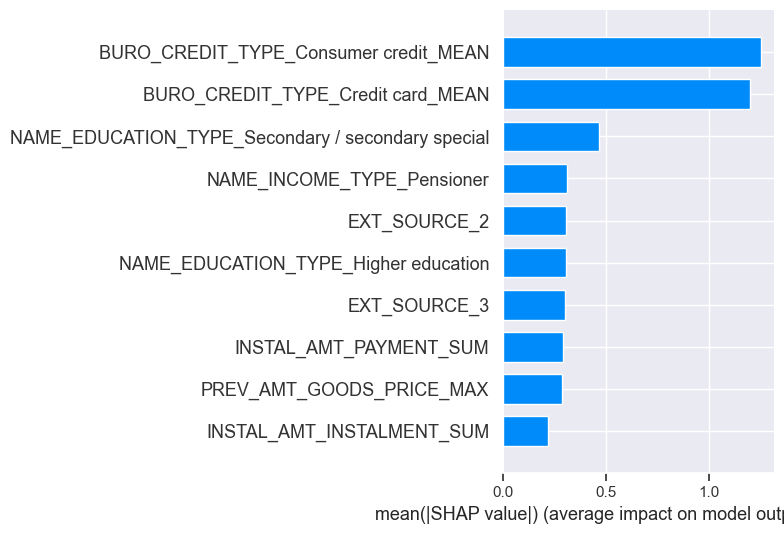

✔️ SHAP summary bar saved to artifacts/shap_summary_bar.png


In [46]:
# Explainer doit utiliser le modèle et les données transformées
shap_values_va = explainer(X_va_proc_df)


# ============================
# 3. Summary Plot (barplot)
# ============================

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_va,
    X_va_proc_df,
    plot_type="bar",
    max_display=10,
    show=True  # indispensable pour éviter l'affichage dans notebook
)
plt.tight_layout()

# ============================
# 4. Sauvegarde
# ============================

path = "artifacts/shap_summary_bar.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.close()

mlflow.log_artifact(path)

print("✔️ SHAP summary bar saved to", path)


In [ ]:
SHAP summary bar plot : Le top 10 des variables qui pilotent la probabilité de défaut

- Il montre les features les plus importantes du modèle
- L’importance est mesurée par la valeur moyenne absolue des SHAP values
- Plus la barre est longue → plus la variable influence la prédiction du défaut

1. BURO_CREDIT_TYPE_Consumer credit_MEAN (La moyenne des montants de crédit consommateur trouvés dans le data bureau)
 Plus un client a beaucoup de crédits conso, ou des crédits conso assez élevés plus il est probable qu’il soit surendetté / risque de défaut

2. BURO_CREDIT_TYPE_Credit card_MEAN (Moyenne des montants de crédit carte de crédit)
Trop de crédits cartes → risque élevé (taux d’intérêt élevés, revolving, comportements risqués).

3. NAME_EDUCATION_TYPE_Secondary / secondary special
niveau d’éducation plus bas → probabilité de défaut statistiquement plus élevé
corrélé aux revenus / stabilité de l’emploi

4. NAME_INCOME_TYPE_Pensioner (Type de revenu "Retraité")

5. EXT_SOURCE_2

6. NAME_EDUCATION_TYPE_Higher education (Education sup


.

In [47]:
#SHAP values sur X_va

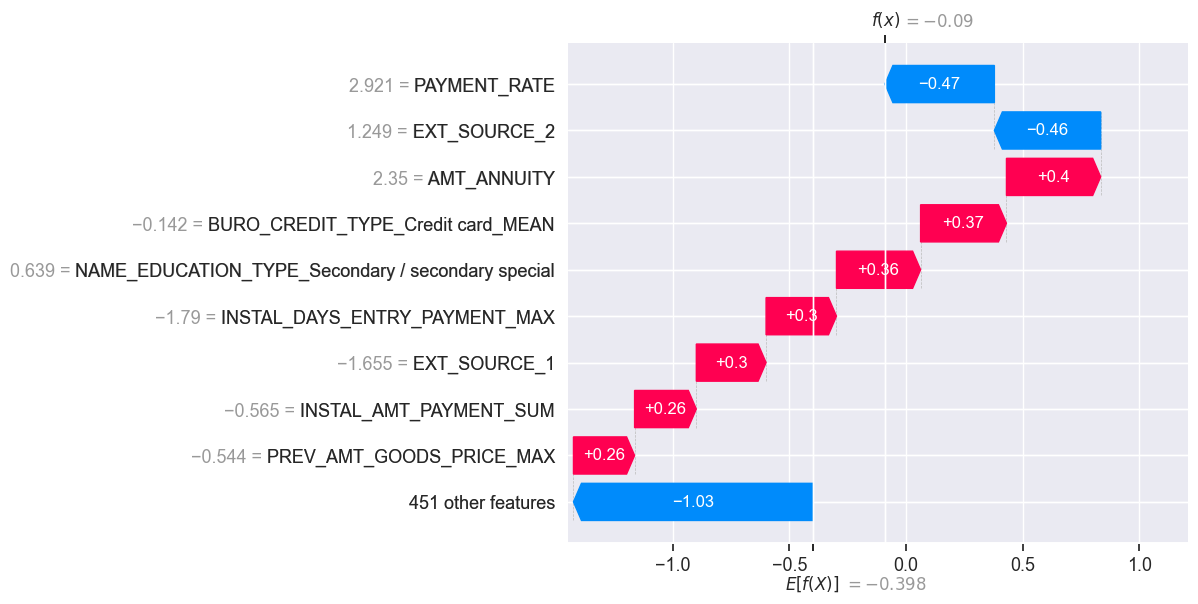

In [48]:
# exemple
i=0
plt.figure()
shap.plots.waterfall(
    shap_values_va[i],
    max_display=10,
    show=True
)
plt.tight_layout()
plt.savefig("artifacts/shap_scatter_client_0.png", dpi=150)
plt.close()
mlflow.log_artifact("artifacts/shap_scatter_client_0.png")




Ce tableau représente pour UN client (client i=0), quelles variables augmentent ou diminuent son risque de défaut, et de combien.

Pour chaque feature:
- value → la valeur du feature
- impact → la contribution SHAP (positive = ↑ risque, négative = ↓ risque)
- impact_direction → interprétation qualitative

Donc :
Plus l’impact est grand en positif → plus cela augmente la proba de défaut
Plus l’impact est négatif → plus cela réduit la proba de défaut


| Variable                                       | Valeur client              | Impact SHAP | Sens                                             |
| ---------------------------------------------- | -------------------------- | ----------- | ------------------------------------------------ |
| **PAYMENT_RATE = 2.921**                       | Très haut taux de paiement | **–0.47**   | 🔵 Réduit fortement le risque                    |
| **EXT_SOURCE_2 = 1.249**                       | Bon score externe          | **–0.46**   | 🔵 Réduit le risque                              |
| **AMT_ANNUITY = 2.35**                         | Mensualité moyenne         | **+0.40**   | 🔴 Augmente un peu le risque (charge financière) |
| **BURO_CREDIT_TYPE_Credit card_MEAN = –0.142** | Présence de crédits carte  | **+0.37**   | 🔴 Augmente le risque                            |
| **NAME_EDUCATION_TYPE_Secondary = 0.639**      | Niveau d’étude moyen       | **+0.36**   | 🔴 Augmente le risque                            |
| **INSTAL_DAYS_ENTRY_PAYMENT_MAX = –1.79**      | Paiements anciens          | **+0.30**   | 🔴 Légère hausse du risque                       |
| **EXT_SOURCE_1 = –1.655**                      | Score externe bas          | **+0.30**   | 🔴 Augmente le risque                            |
| **INSTAL_AMT_PAYMENT_SUM = –0.565**            | Paiements totaux bas       | **+0.26**   | 🔴 Risque légèrement accru                       |
| **PREV_AMT_GOODS_PRICE_MAX = –0.544**          | Biens peu chers            | **+0.26**   | 🔴 Augmente un peu le risque                     |
| **451 autres features**                        |                            | **–1.03**   | 🔵 Effet cumulatif global positif                |


In [49]:
import joblib, json
# ============================================================
# sauvegarde du modèle + métadonnées
# ============================================================

os.makedirs("models", exist_ok=True)

# Sauvegarde du modèle entraîné
joblib.dump(final_model, "models/credit_risk_model.pkl")
mlflow.log_artifact("models/credit_risk_model.pkl")

# Sauvegarde des métadonnées : seuil, coût, features, version
metadata = {
    "threshold": float(best_t),
    "cost_fn": float(COST_FN),
    "cost_fp": float(COST_FP),
    "features": list(X.columns),
    "model_version": "logreg_weight_v1"
}

with open("models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

mlflow.log_artifact("models/metadata.json")
# Log MLflow du modèle pour usage ultérieur
mlflow.sklearn.log_model(final_model, name="sklearn_model")

print("\nModèle et métadonnées sauvegardés dans le dossier 'models/'")



2025/11/21 15:09:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Modèle et métadonnées sauvegardés dans le dossier 'models/'


In [50]:
pip show evidently

Name: evidently
Version: 0.7.16
Summary: Open-source tools to analyze, monitor, and debug machine learning model in production.
Home-page: https://github.com/evidentlyai/evidently
Author: Emeli Dral
Author-email: emeli.dral@gmail.com
License: 
Location: C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: certifi, cryptography, deprecation, dynaconf, fsspec, iterative-telemetry, litestar, nltk, numpy, pandas, plotly, pydantic, PyYAML, requests, rich, scikit-learn, scipy, statsmodels, typer, typing-inspect, ujson, urllib3, uuid6, uvicorn, watchdog
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [55]:
# =========================
# DATA Drift - Evidently 0.7.16
# =========================

import pandas as pd
from evidently import Report
from evidently import Dataset, DataDefinition
from evidently.descriptors import Sentiment, TextLength, Contains
from evidently.presets import TextEvals, DataDriftPreset
#from sys import path

# données
common_cols = [c for c in X.columns if c in X_test.columns]
ref_data = X[common_cols]
cur_data = X_test[common_cols]

report = Report([
    DataDriftPreset(method="psi")
],
include_tests="True")

# The .run() method remains the same
result = report.run(reference_data=ref_data, current_data=cur_data)



#path("artifacts").mkdir(exist_ok=True)
html_path = "artifacts/data_drift_report.html"

# The save_html method remains the same
result.save_html(html_path)

print(f"✔️ Rapport Evidently généré : {html_path}")
mlflow.log_artifact(html_path)

mlflow.end_run()
print("Run MLflow terminé")

# Note: In version 0.7.x, the output will be a TestSuite result (Pass/Fail)
# rather than the full visual Report available in modern versions.

✔️ Rapport Evidently généré : artifacts/data_drift_report.html
Run MLflow terminé ✅


In [ ]:
# objectif métier = détecter un maximum de défauts sans perdre trop de précision

| Élément                           | Signification                                                                                                              |
| --------------------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| **Seuil = 0.520**                 | le modèle doit classer un client comme “défaillant” s’il a **plus de 52 %** de probabilité estimée.                       |
| **Coût minimal = 2966**           | En appliquant ce seuil, on minimise le **coût métier global** (faux négatifs + faux positifs pondérés).                  |
| **COST_FN / COST_FP = 0.9 / 0.1** | on a décidé qu’un **faux négatif (défaut non détecté)** coûte 9× plus cher qu’un **faux positif (client refusé à tort)**. |


En d’autres termes

le seuil plus bas (< 0.52) → ON détecte plus de mauvais clients,
mais tu refuses plus de bons → ton coût augmente à cause des faux positifs.

Si tu mets le seuil plus haut (> 0.52) → On accepte plus de mauvais clients,
donc le coût augmente à cause des faux négatifs.

Le 0.52 équilibre ces deux effets selon tes poids métier (0.9 / 0.1).

In [ ]:
#!pip uninstall -y evidently
#!pip install evidently
!pip show evidently